<a href="https://colab.research.google.com/github/elianramon/Titanic/blob/main/TITANNIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Titanic

In [44]:
import seaborn as sns

## Import DataSets

In [45]:
import pandas as pd

url = "https://raw.githubusercontent.com/elianramon/Titanic/refs/heads/main/train.csv"
df1 = pd.read_csv(url)

url2 = "https://raw.githubusercontent.com/elianramon/Titanic/refs/heads/main/test.csv"
df2 = pd.read_csv(url2)

url3 = "https://raw.githubusercontent.com/elianramon/Titanic/refs/heads/main/gender_submission.csv"
df3 = pd.read_csv(url3)

df4 = pd.merge(df2, df3, on='PassengerId')

df = pd.concat([df1, df4], ignore_index=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Drop Columns

In [46]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [47]:
df = df.drop(['PassengerId','Cabin', 'Ticket', 'SibSp',	'Parch',	'Fare', 'Cabin','Embarked'], axis=1)
df

,Survived,Pclass,Name,Sex,Age
0,0,3,"Braund, Mr. Owen Harris",male,22.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,1,3,"Heikkinen, Miss. Laina",female,26.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,0,3,"Allen, Mr. William Henry",male,35.0
...,...,...,...,...,...
1304,0,3,"Spector, Mr. Woolf",male,NaN
1305,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0
1306,0,3,"Saether, Mr. Simon Sivertsen",male,38.5
1307,0,3,"Ware, Mr. Frederick",male,NaN


## Infor

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1309 non-null   int64  
 1   Pclass    1309 non-null   int64  
 2   Name      1309 non-null   object 
 3   Sex       1309 non-null   object 
 4   Age       1046 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 51.3+ KB


In [49]:
df = df.dropna(subset=['Age']).reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1046 entries, 0 to 1045
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1046 non-null   int64  
 1   Pclass    1046 non-null   int64  
 2   Name      1046 non-null   object 
 3   Sex       1046 non-null   object 
 4   Age       1046 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 41.0+ KB


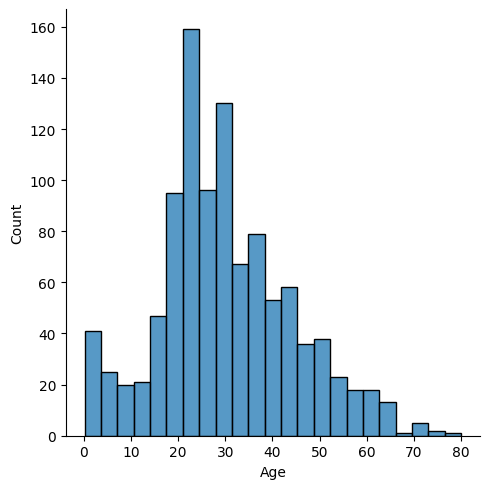

In [50]:
sns.displot(df['Age'])

In [51]:
df['Pclass'].value_counts()

,count
Pclass,
3,501
1,284
2,261


In [52]:
df.groupby('Pclass')['Age'].mean()

,Age
Pclass,
1,39.159930
2,29.506705
3,24.816367


In [53]:
df.groupby('Sex')['Age'].mean()

,Age
Sex,
female,28.687088
male,30.585228


In [54]:
#imprimindo todos os detalhes do sobrevivente

sobreviventes = df[df[ 'Survived' ]== 1]
sobreviventes

,Survived,Pclass,Name,Sex,Age
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,1,3,"Heikkinen, Miss. Laina",female,26.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
7,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0
8,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0
...,...,...,...,...,...
1035,1,1,"Gibson, Miss. Dorothy Winifred",female,22.0
1041,1,3,"Peacock, Miss. Treasteall",female,3.0
1042,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0
1043,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0


In [55]:
mortos = df[df[ 'Survived' ]== 0]
mortos

,Survived,Pclass,Name,Sex,Age
0,0,3,"Braund, Mr. Owen Harris",male,22.0
4,0,3,"Allen, Mr. William Henry",male,35.0
5,0,1,"McCarthy, Mr. Timothy J",male,54.0
6,0,3,"Palsson, Master. Gosta Leonard",male,2.0
11,0,3,"Saundercock, Mr. William Henry",male,20.0
...,...,...,...,...,...
1037,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.0
1038,0,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0
1039,0,2,"Ware, Mr. William Jeffery",male,23.0
1040,0,1,"Widener, Mr. George Dunton",male,50.0


In [57]:
Mu_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'female')].shape[0]
Ho_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'male')].shape[0]

Mu_morte = df[(df['Survived'] == 0) & (df['Sex'] == 'female')].shape[0]
Ho_morte = df[(df['Survived'] == 0) & (df['Sex'] == 'male')].shape[0]


print(f'Mulheres sobreviventes: {Mu_sobreviventes}')
print(f'Mulheres mortas: {Mu_morte}')
print(f'Homens sobreviventes: {Ho_sobreviventes}')
print(f'Homens mostos: {Ho_morte}')

Mulheres sobreviventes: 324
Mulheres mortas: 64
Homens sobreviventes: 93
Homens mostos: 565


In [59]:
print('Mulheres vivas: ',(Mu_sobreviventes *100 )/ df[df['Sex']=='female'].shape[0])

print('Homens vivos: ',(Ho_sobreviventes *100 )/ df[df['Sex']=='male'].shape[0])


Mulheres vivas:  83.50515463917526
Homens vivos:  14.133738601823708


In [60]:
# Crianças (Idade <= 12) que sobreviveram
Cri_sobreviventes = df[(df['Survived'] == 1) & (df['Age'] <= 12)].shape[0]

# Crianças (Idade <= 12) que não sobreviveram
Cri_morte = df[(df['Survived'] == 0) & (df['Age'] <= 12)].shape[0]

print(f'Crianças sobreviventes: {Cri_sobreviventes}')
print(f'Crianças mortas: {Cri_morte}')

Crianças sobreviventes: 52
Crianças mortas: 42


In [63]:
Mu_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'female')& (df['Age'] <= 12)].shape[0]
Ho_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'male')& (df['Age'] <= 12)].shape[0]

Mu_morte = df[(df['Survived'] == 0) & (df['Sex'] == 'female')& (df['Age'] <= 12)].shape[0]
Ho_morte = df[(df['Survived'] == 0) & (df['Sex'] == 'male')& (df['Age'] <= 12)].shape[0]


print(f'Mulheres crianças sobreviventes: {Mu_sobreviventes}')
print(f'Mulheres crianças mortas: {Mu_morte}')
print(f'Homens crianças sobreviventes: {Ho_sobreviventes}')
print(f'Homens crianças mostos: {Ho_morte}')

Mulheres crianças sobreviventes: 31
Mulheres crianças mortas: 13
Homens crianças sobreviventes: 21
Homens crianças mostos: 29


In [64]:
Mu_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'female') & (df['Pclass']==1)].shape[0]
Mu_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'female') & (df['Pclass']==2)].shape[0]
Mu_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'female') & (df['Pclass']==3)].shape[0]


# Ho_sobreviventes = df[(df['Survived'] == 1) & (df['Sex'] == 'male')].shape[0]

# Mu_morte = df[(df['Survived'] == 0) & (df['Sex'] == 'female')].shape[0]
# Ho_morte = df[(df['Survived'] == 0) & (df['Sex'] == 'male')].shape[0]


# print(f'Mulheres sobreviventes: {Mu_sobreviventes}')
# print(f'Mulheres mortas: {Mu_morte}')
# print(f'Homens sobreviventes: {Ho_sobreviventes}')
# print(f'Homens mostos: {Ho_morte}')

130

In [66]:
# Filtra apenas mulheres sobreviventes e conta os valores da coluna Pclass
Mulher_Viva_classe = df[(df['Survived'] == 1) & (df['Sex'] == 'female')]['Pclass'].value_counts()
Mulher_Morta_classe = df[(df['Survived'] == 0) & (df['Sex'] == 'female')]['Pclass'].value_counts()
Homem_Vivo_classe = df[(df['Survived'] == 1) & (df['Sex'] == 'male')]['Pclass'].value_counts()
Homem_Morto_classe = df[(df['Survived'] == 0) & (df['Sex'] == 'male')]['Pclass'].value_counts()


print(f'Mulheres sobreviventes: {Mulher_Viva_classe}')
print(f'Mulheres mortas: {Mulher_Morta_classe}')
print(f'Homens sobreviventes: {Homem_Vivo_classe}')
print(f'Homens mostos: {Homem_Morto_classe}')

Mulheres sobreviventes: Pclass
1    130
3     97
2     97
Name: count, dtype: int64
Mulheres mortas: Pclass
3    55
2     6
1     3
Name: count, dtype: int64
Homens sobreviventes: Pclass
1    40
3    38
2    15
Name: count, dtype: int64
Homens mostos: Pclass
3    311
2    143
1    111
Name: count, dtype: int64
